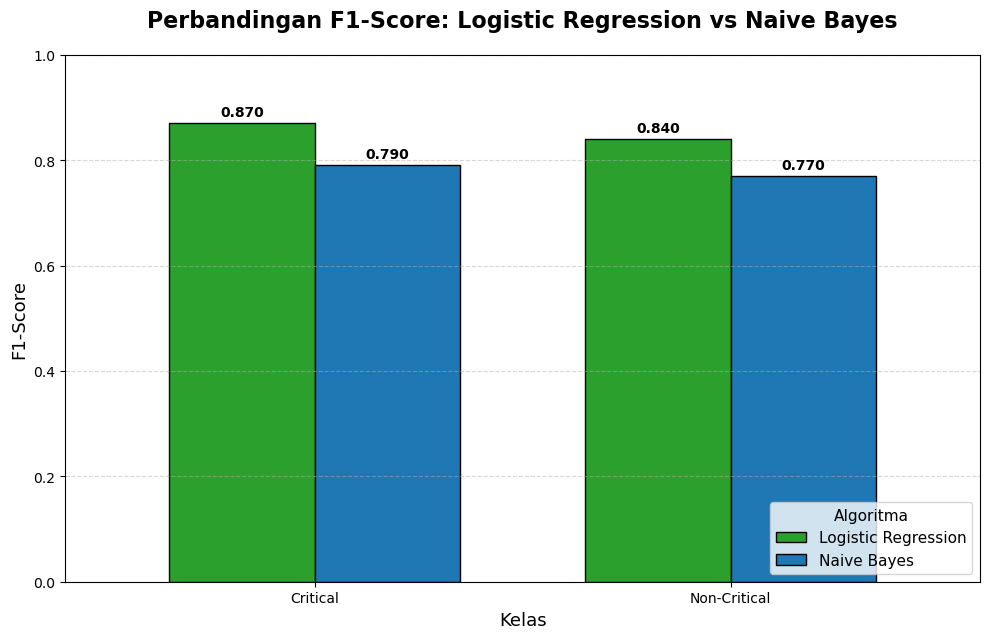

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. MASUKKAN DATA F1-SCORE ASLI ANDA DI SINI
# =========================================================
# Data F1-Score untuk Logistic Regression (LR)
f1_lr_critical = 0.87
f1_lr_non_critical = 0.84

# Data F1-Score untuk Naive Bayes (NB)
f1_nb_critical = 0.79 
f1_nb_non_critical = 0.77 

# =========================================================
# 2. STRUKTURISASI DATA UNTUK PENGGAMBARAN
# =========================================================
data_comparison = {
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Critical': [f1_lr_critical, f1_nb_critical],
    'Non-Critical': [f1_lr_non_critical, f1_nb_non_critical]
}

# Ubah menjadi DataFrame
df_compare = pd.DataFrame(data_comparison)

# Mengatur 'Model' sebagai indeks untuk memudahkan plotting grouped bar
df_plot = df_compare.set_index('Model')

# =========================================================
# 3. PROSES VISUALISASI SEABORN/MATPLOTLIB
# =========================================================
# Buat kanvas gambar
fig, ax = plt.subplots(figsize=(10, 6.5))

# Tentukan posisi untuk grouped bar
models = df_plot.index
x_pos = np.arange(len(models))  # Posisi label model di sumbu X
width = 0.35  # Lebar batang tunggal

# Gambar Batang 1 (Critical)
bar1 = ax.bar(x_pos - width/2, df_plot['Critical'], width, 
              label='Critical', color='#1f77b4', edgecolor='black') # Biru

# Gambar Batang 2 (Non-Critical)
bar2 = ax.bar(x_pos + width/2, df_plot['Non-Critical'], width, 
              label='Non-Critical', color='#ff7f0e', edgecolor='black') # Oranye

# =========================================================
# 4. PENYESUAIAN LABEL DAN TAMPILAN SESUAI REQUEST
# =========================================================
# Judul utama grafik
plt.title('Perbandingan F1-Score per Kelas', fontsize=16, pad=20, fontweight='bold')

# Label sumbu Y
plt.ylabel('F1-Score', fontsize=13)


# --- JALUR PERBAIKAN AGAR PAS DENGAN GAMBAR ---
plt.close('all') 

data_per_kelas = {
    'Kelas': ['Critical', 'Non-Critical'],
    'Logistic Regression': [f1_lr_critical, f1_lr_non_critical],
    'Naive Bayes': [f1_nb_critical, f1_nb_non_critical]
}

# DataFrame baru
df_per_kelas = pd.DataFrame(data_per_kelas)
df_per_kelas_plot = df_per_kelas.set_index('Kelas')

# Buat kanvas baru
fig, ax = plt.subplots(figsize=(10, 6.5))

# Plotting Grouped Bar dari pandas DataFrame
df_per_kelas_plot.plot(kind='bar', ax=ax, rot=0, 
                       color=['#2ca02c', '#1f77b4'], # Hijau vs Biru
                       edgecolor='black', width=0.7)

# Judul
plt.title('Perbandingan F1-Score: Logistic Regression vs Naive Bayes', fontsize=16, pad=20, fontweight='bold')

# Sumbu Y
plt.ylabel('F1-Score', fontsize=13)

# Sumbu X 
plt.xlabel('Kelas', fontsize=13)
# Sumbu Y diset dari 0 sampai 1
plt.ylim(0, 1.0)
# Tambahkan grid horizontal putus-putus
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan legenda di pojok kanan bawah
plt.legend(title='Algoritma', loc='lower right', fontsize=11, title_fontsize=11)

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), # Jarak teks ke atas batang
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()

# Simpan gambarnya untuk laporan
plt.savefig('../reports/f1_score_comparison_grouped.png', dpi=300)

plt.show()

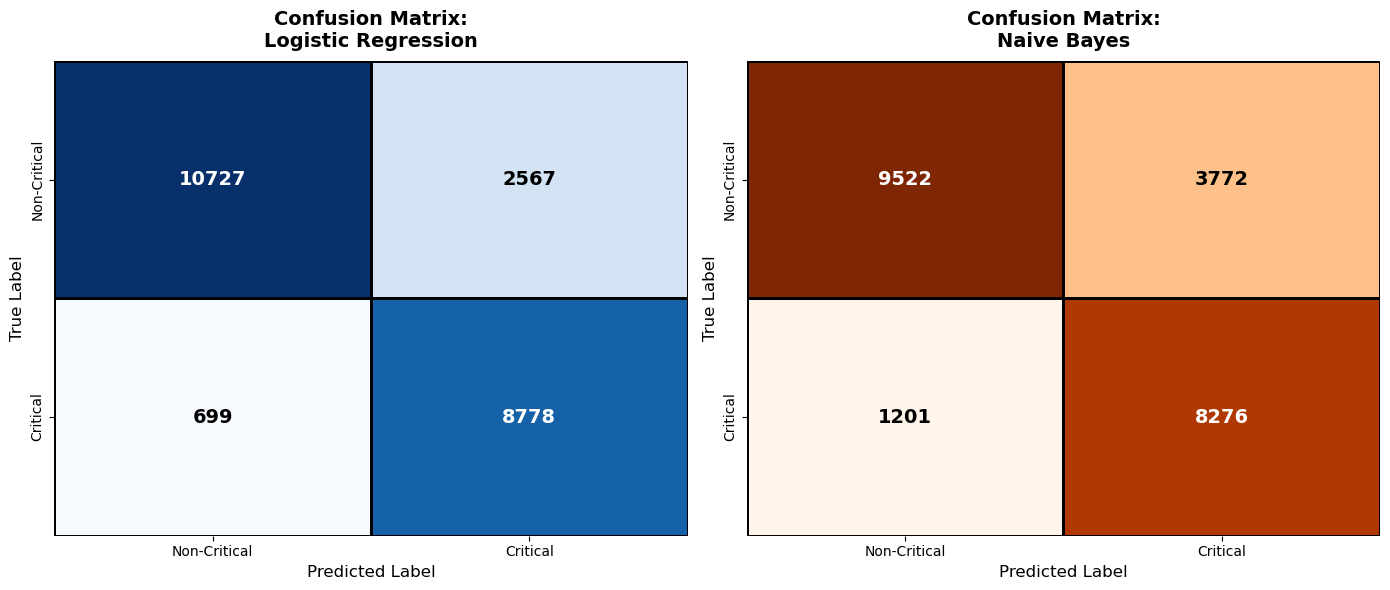

PERBANDINGAN CONFUSION MATRIX

--- LOGISTIC REGRESSION ---
Confusion Matrix:
[[10727  2567]
 [  699  8778]]
True Negatives (TN):  10727
False Positives (FP): 2567
False Negatives (FN): 699
True Positives (TP):  8778

Accuracy:  0.8566
Precision: 0.7737
Recall:    0.9262

--- NAIVE BAYES ---
Confusion Matrix:
[[9522 3772]
 [1201 8276]]
True Negatives (TN):  9522
False Positives (FP): 3772
False Negatives (FN): 1201
True Positives (TP):  8276

Accuracy:  0.7816
Precision: 0.6869
Recall:    0.8733

PERBANDINGAN RINGKAS
   Metric Logistic Regression Naive Bayes
 Accuracy              0.8566      0.7816
Precision              0.7737      0.6869
   Recall              0.9262      0.8733


In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# PERBANDINGAN CONFUSION MATRIX: LOGISTIC REGRESSION vs NAIVE BAYES
# =========================================================

# Load Data
with open('../data/processed/data_splits_tfidf.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_test = data_splits['X_test']
y_test = data_splits['y_test']

# Load Models
with open('../data/processed/model_lr_tuned_biner.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('../data/processed/model_nb_biner.pkl', 'rb') as f:
    model_nb = pickle.load(f)

# Prediksi
y_pred_lr = model_lr.predict(X_test)
y_pred_nb = model_nb.predict(X_test)

# Hitung Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Label mapping
labels_map = ['Non-Critical', 'Critical']

# =========================================================
# VISUALISASI 
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LOGISTIC REGRESSION ---
# Buat heatmap tanpa annotation
sns.heatmap(cm_lr, 
            annot=False,
            fmt='d',
            cmap='Blues',
            xticklabels=labels_map,
            yticklabels=labels_map,
            ax=axes[0],
            cbar=False,
            linewidths=2,
            linecolor='black')

thresh_lr = cm_lr.max() / 2
for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        color = "white" if cm_lr[i, j] > thresh_lr else "black"
        axes[0].text(j + 0.5, i + 0.5, 
                    f'{cm_lr[i, j]}',
                    ha='center', va='center',
                    color=color,
                    fontsize=14, fontweight='bold')

axes[0].set_title('Confusion Matrix:\nLogistic Regression', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# --- NAIVE BAYES ---
sns.heatmap(cm_nb, 
            annot=False,
            fmt='d',
            cmap='Oranges',
            xticklabels=labels_map,
            yticklabels=labels_map,
            ax=axes[1],
            cbar=False,
            linewidths=2,
            linecolor='black')

thresh_nb = cm_nb.max() / 2
for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        color = "white" if cm_nb[i, j] > thresh_nb else "black"
        axes[1].text(j + 0.5, i + 0.5, 
                    f'{cm_nb[i, j]}',
                    ha='center', va='center',
                    color=color,
                    fontsize=14, fontweight='bold')

axes[1].set_title('Confusion Matrix:\nNaive Bayes', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Cetak Ringkasan Metrics
print("=" * 80)
print("PERBANDINGAN CONFUSION MATRIX")
print("=" * 80)

print("\n--- LOGISTIC REGRESSION ---")
print(f"Confusion Matrix:\n{cm_lr}")
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
print(f"True Negatives (TN):  {tn_lr}")
print(f"False Positives (FP): {fp_lr}")
print(f"False Negatives (FN): {fn_lr}")
print(f"True Positives (TP):  {tp_lr}")

accuracy_lr = (tp_lr + tn_lr) / (tp_lr + tn_lr + fp_lr + fn_lr)
precision_lr = tp_lr / (tp_lr + fp_lr) if (tp_lr + fp_lr) > 0 else 0
recall_lr = tp_lr / (tp_lr + fn_lr) if (tp_lr + fn_lr) > 0 else 0
print(f"\nAccuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")

print("\n--- NAIVE BAYES ---")
print(f"Confusion Matrix:\n{cm_nb}")
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()
print(f"True Negatives (TN):  {tn_nb}")
print(f"False Positives (FP): {fp_nb}")
print(f"False Negatives (FN): {fn_nb}")
print(f"True Positives (TP):  {tp_nb}")

accuracy_nb = (tp_nb + tn_nb) / (tp_nb + tn_nb + fp_nb + fn_nb)
precision_nb = tp_nb / (tp_nb + fp_nb) if (tp_nb + fp_nb) > 0 else 0
recall_nb = tp_nb / (tp_nb + fn_nb) if (tp_nb + fn_nb) > 0 else 0
print(f"\nAccuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")

print("\n" + "=" * 80)
print("PERBANDINGAN RINGKAS")
print("=" * 80)
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Logistic Regression': [f"{accuracy_lr:.4f}", f"{precision_lr:.4f}", f"{recall_lr:.4f}"],
    'Naive Bayes': [f"{accuracy_nb:.4f}", f"{precision_nb:.4f}", f"{recall_nb:.4f}"]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("=" * 80)

MENGHITUNG LEARNING CURVE: LOGISTIC REGRESSION
[learning_curve] Training set sizes: [ 3643  8587 13532 18476 23421 28366 33310 38255 43199 48144 53088 58033
 62977 67922 72867]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed:   27.3s finished



MENGHITUNG LEARNING CURVE: NAIVE BAYES
[learning_curve] Training set sizes: [ 3643  8587 13532 18476 23421 28366 33310 38255 43199 48144 53088 58033
 62977 67922 72867]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed:    4.8s finished


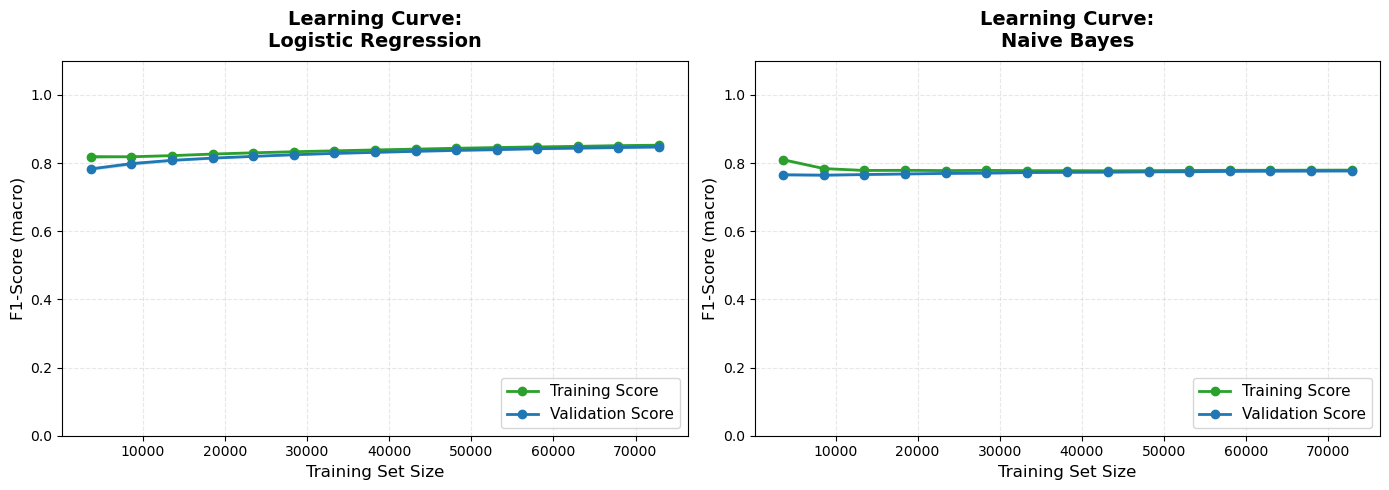


Learning curve berhasil dibuat dan disimpan ke: ../reports/learning_curve_comparison.png


In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# =========================================================
# LEARNING CURVE: LOGISTIC REGRESSION vs NAIVE BAYES
# =========================================================

# Load Data
with open('../data/processed/data_splits_tfidf.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_train = data_splits['X_train']
y_train = data_splits['y_train']
X_test = data_splits['X_test']
y_test = data_splits['y_test']

# Load Models
with open('../data/processed/model_lr_tuned_biner.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('../data/processed/model_nb_biner.pkl', 'rb') as f:
    model_nb = pickle.load(f)

# =========================================================
# FUNGSI UNTUK PLOT LEARNING CURVE
# =========================================================
def plot_learning_curves(estimator, X, y, title, ax, cv=5, train_sizes=None):
    """
    Plot learning curve untuk suatu model
    """
    if train_sizes is None:
        train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, 
        cv=cv, 
        train_sizes=train_sizes,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    
    # Hitung mean dan std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot
    ax.plot(train_sizes, train_mean, 'o-', color='#2ca02c', label='Training Score', linewidth=2, markersize=6)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2ca02c')
    
    ax.plot(train_sizes, val_mean, 'o-', color='#1f77b4', label='Validation Score', linewidth=2, markersize=6)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#1f77b4')
    
    ax.set_xlabel('Training Set Size', fontsize=12)
    ax.set_ylabel('F1-Score (macro)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

# =========================================================
# PLOTTING LEARNING CURVES
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definisi train_sizes untuk konsistensi
train_sizes = np.linspace(0.05, 1.0, 15)

# --- Logistic Regression ---
print("=" * 80)
print("MENGHITUNG LEARNING CURVE: LOGISTIC REGRESSION")
print("=" * 80)
plot_learning_curves(model_lr, X_train, y_train, 
                     'Learning Curve:\nLogistic Regression',
                     axes[0], cv=5, train_sizes=train_sizes)

# --- Naive Bayes ---
print("\n" + "=" * 80)
print("MENGHITUNG LEARNING CURVE: NAIVE BAYES")
print("=" * 80)
plot_learning_curves(model_nb, X_train, y_train,
                     'Learning Curve:\nNaive Bayes',
                     axes[1], cv=5, train_sizes=train_sizes)

plt.tight_layout()
plt.savefig('../reports/learning_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("Learning curve berhasil dibuat dan disimpan ke: ../reports/learning_curve_comparison.png")
print("=" * 80)